# Plotting API Usage

This notebook defines synthetic experiment outputs and applies stateless plotting maps. It is an API reference, not an experiment.

## Reader Guide

Inputs:

- `df`: one row per run, with columns such as method, dimension, loss, runtime, and steps
- `trajectories`: a map from `(algo, d, seed)` to the loss sequence $\{\ell_t\}_{t\ge 0}$

Outputs are Matplotlib figures. Read this notebook only to modify shared plotting functions or reproduce the visual style used in E01-E10.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT = Path.cwd().resolve()
if not (PROJECT / "plotting").exists():
    PROJECT = PROJECT.parent.resolve()
sys.path.insert(0, str(PROJECT))

from plotting import (
    PLOT_COLORS,
    ordered_algos_in,
    ordered_dims_in,
    plot_algorithm_dimension_grid,
    plot_algorithms_for_dimension,
    plot_all_mean_curves_combined,
    plot_color_key,
    plot_dimensions_for_algorithm,
    plot_metric_bar,
    plot_metric_overview,
    plot_seed_variability_for_dimension,
    summary_table,
)


def show_figure(fig):
    display(fig)
    plt.close(fig)

## Toy Inputs

The real experiment notebook produces these two objects in memory:

- `df`: one row per run
- `trajectories`: keyed by `(algo, d, seed)` with per-step loss lists

In [2]:
ALGOS = ["Muon", "Muon-Exact", "Shampoo", "Adam", "SGD"]
DIMS = [20, 30]
SEEDS = range(3)
ITERS = 60

rate = {"Muon": 0.075, "Muon-Exact": 0.082, "Shampoo": 0.06, "Adam": 0.052, "SGD": 0.038}
scale = {"Muon": 0.75, "Muon-Exact": 0.72, "Shampoo": 0.9, "Adam": 1.0, "SGD": 1.15}

rows = []
trajectories = {}
rng = np.random.default_rng(0)
for algo in ALGOS:
    for d in DIMS:
        for seed in SEEDS:
            steps = np.arange(ITERS)
            noise = rng.normal(0.0, 0.01, size=ITERS)
            loss = scale[algo] * np.exp(-rate[algo] * steps * (20 / d)) + 0.01 + np.abs(noise)
            trajectories[(algo, d, seed)] = {"loss": loss.tolist(), "grad_norm": np.sqrt(loss).tolist()}
            rows.append({
                "problem": "ToyMatrixSensing",
                "algo": algo,
                "d": d,
                "seed": seed,
                "iters": ITERS,
                "actual_steps": ITERS,
                "stopped_early": False,
                "min_loss": float(loss.min()),
                "final_loss": float(loss[-1]),
                "time_s": float((d / 20) * scale[algo] * (1.0 + seed / 20)),
            })

df = pd.DataFrame(rows)
display(df.head())
display(summary_table(df))

,problem,algo,d,seed,iters,actual_steps,stopped_early,min_loss,final_loss,time_s
0,ToyMatrixSensing,Muon,20,0,60,60,False,0.025226,0.025598,0.75000
1,ToyMatrixSensing,Muon,20,1,60,60,False,0.025938,0.030629,0.78750
2,ToyMatrixSensing,Muon,20,2,60,60,False,0.021380,0.021380,0.82500
3,ToyMatrixSensing,Muon,30,0,60,60,False,0.060678,0.060678,1.12500
4,ToyMatrixSensing,Muon,30,1,60,60,False,0.056396,0.057584,1.18125


,algo,d,runs,min_loss_mean,final_loss_mean,time_s_mean,actual_steps_mean,stopped_early_rate
0,Adam,20,3,0.063004,0.065251,1.05000,60.0,0.0
1,Adam,30,3,0.145995,0.148253,1.57500,60.0,0.0
2,Muon,20,3,0.024181,0.025869,0.78750,60.0,0.0
3,Muon,30,3,0.057548,0.059150,1.18125,60.0,0.0
4,Muon-Exact,20,3,0.018794,0.023461,0.75600,60.0,0.0
5,Muon-Exact,30,3,0.043136,0.043831,1.13400,60.0,0.0
6,SGD,20,3,0.136826,0.136833,1.20750,60.0,0.0
7,SGD,30,3,0.271935,0.271935,1.81125,60.0,0.0
8,Shampoo,20,3,0.039182,0.044437,0.94500,60.0,0.0
9,Shampoo,30,3,0.104268,0.105755,1.41750,60.0,0.0


## Shared Colors

In [3]:
PLOT_COLORS

{'algorithms': {'Muon': '#0072B2',
  'Muon-Exact': '#56B4E9',
  'Muon-NS-1': '#1F9AC7',
  'Muon-NS-10': '#085C83',
  'Muon-Truncated': '#7B92D4',
  'Muon-RandSVD': '#5E3C99',
  'Shampoo': '#009E73',
  'Adam': '#D55E00',
  'SGD': '#CC79A7',
  'NormalizedSGD': '#E69F00',
  'SpectralNormSGD': '#A6761D',
  'LayerwiseNormalizedSGD': '#8C564B'},
 'dimension_base': ('#C6DBEF', '#6BAED6', '#2171B5', '#08306B'),
 'dimension_linestyles': ('-', '--', ':', '-.')}

## Color Key

This is a legend demonstration rather than an experiment result. Optimizer hue and dimension shade/line style are shown separately so that downstream plots can encode method and dimension at the same time.

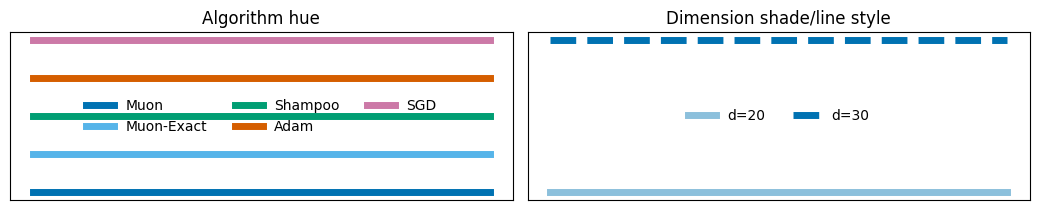

In [4]:
fig, axes = plot_color_key(df)
show_figure(fig)

## Metric Overview

This example consumes a one-row-per-run summary table. The horizontal axis is dimension $d$, color is optimizer, and the panels show executed steps, wall-clock time, and minimum loss. The plotted values are already summary statistics in the toy `df`.

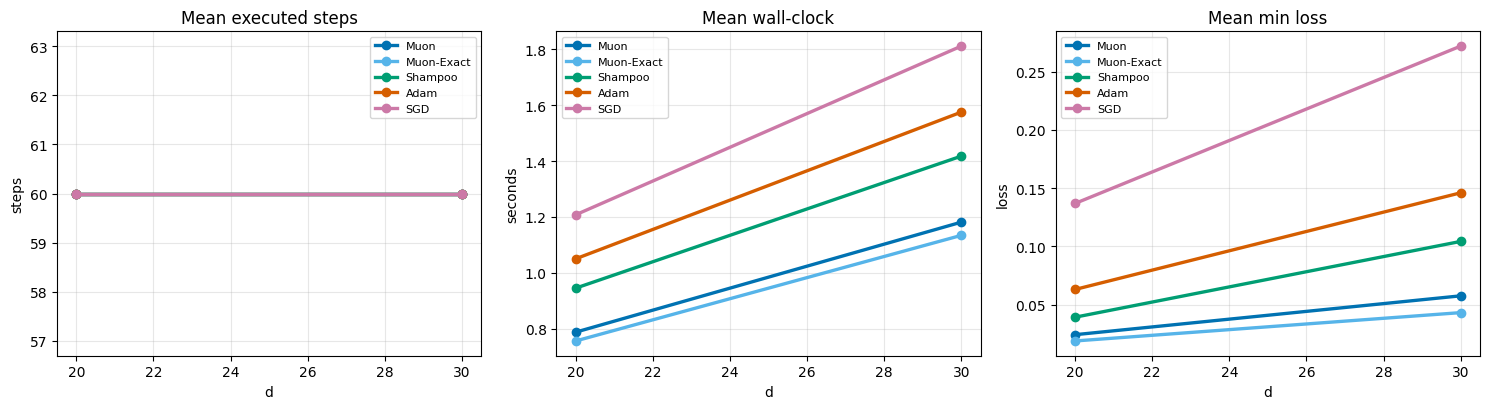

In [5]:
fig, axes = plot_metric_overview(df)
show_figure(fig)

## Metric Bar

The bar group is optimizer and the bar color is dimension. The height is the selected summary column, here `actual_steps_mean`. This demonstrates how the shared plotting function displays one scalar run metric across method and dimension.

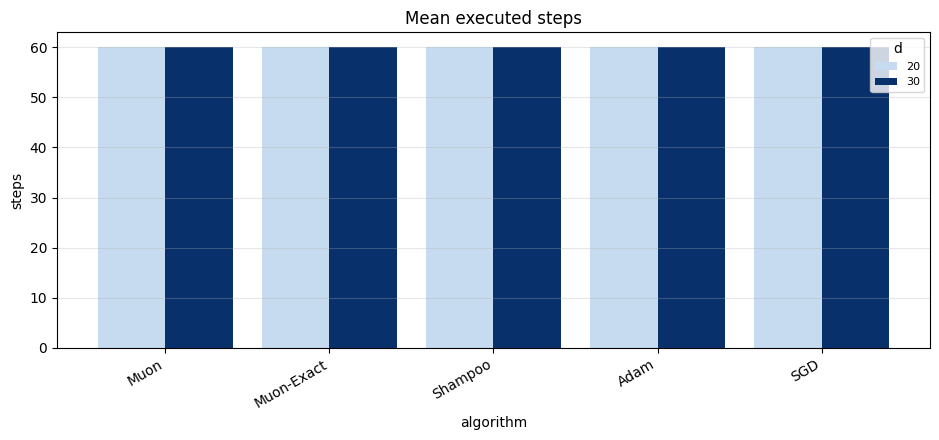

In [6]:
fig, ax = plot_metric_bar(df, "actual_steps_mean", "Mean executed steps", "steps")
show_figure(fig)

## Same Dimension

This example fixes $d=20$. The horizontal axis is step $t$, the vertical axis is seed-mean loss $\ell_t$, and color is optimizer. It demonstrates the common “same problem size, compare methods” plot.

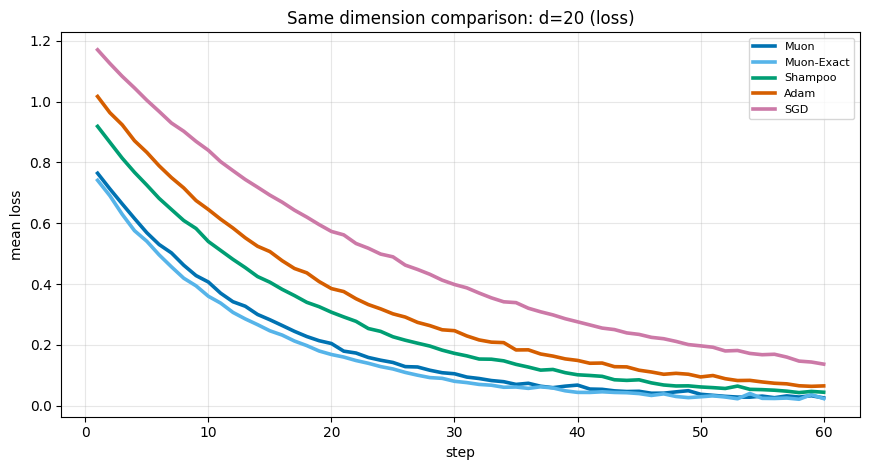

In [7]:
fig, ax = plot_algorithms_for_dimension(trajectories, d=20)
show_figure(fig)

## Same Algorithm

This example fixes optimizer `Muon`. The horizontal axis is step, the vertical axis is seed-mean loss, and shade/line style encodes dimension. It demonstrates the common “same method, compare dimensions” plot.

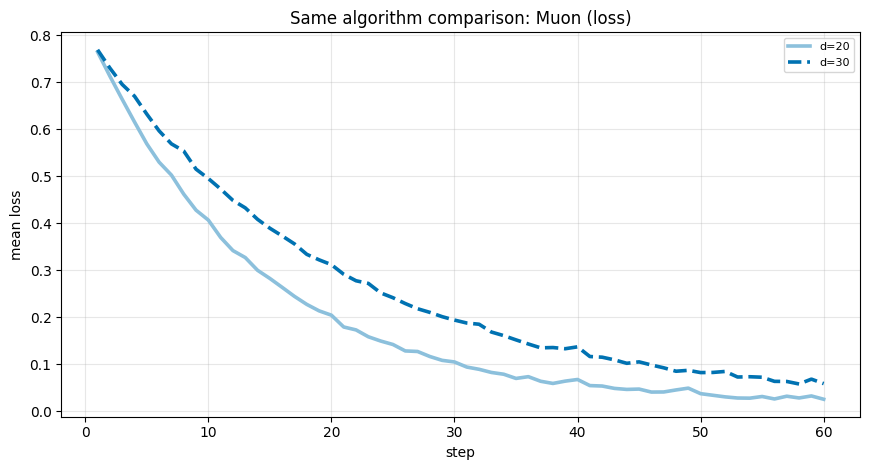

In [8]:
fig, ax = plot_dimensions_for_algorithm(trajectories, algo="Muon")
show_figure(fig)

## All Mean Curves

This combines every `(algo, d)` mean trajectory. The horizontal axis is step and the vertical axis is seed-mean loss. It is useful for a compact overview, but detailed interpretation should use the split plots when many lines overlap.

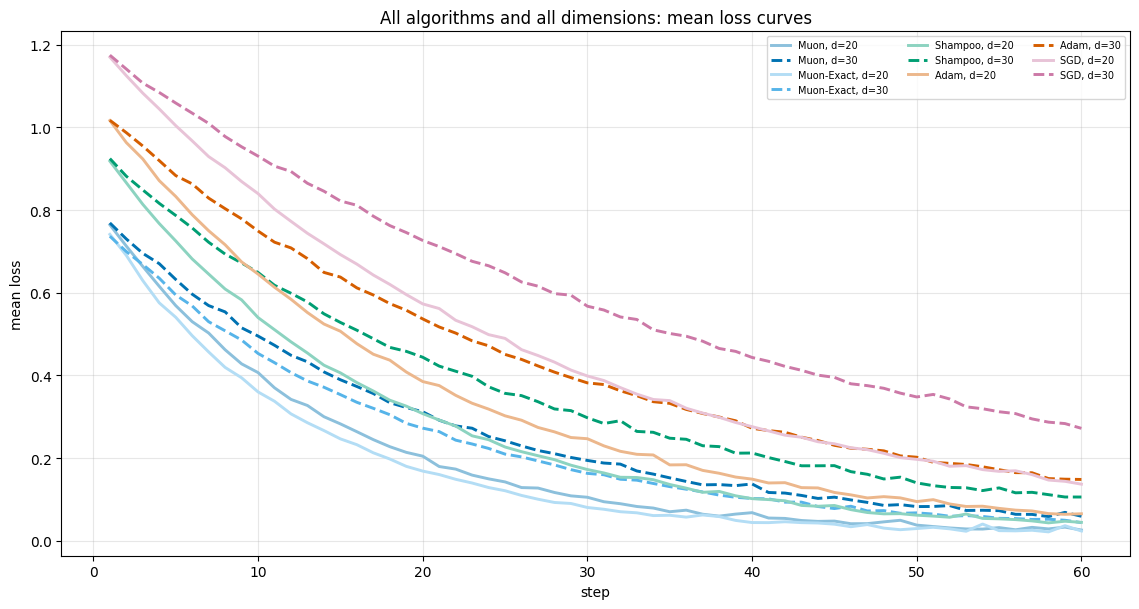

In [9]:
fig, ax = plot_all_mean_curves_combined(trajectories)
show_figure(fig)

## Algorithm-Dimension Grid

Rows correspond to optimizers and columns correspond to dimensions. Each subplot shows the seed-mean loss curve for that pair. This layout keeps the same comparisons as the combined plot while avoiding line overlap.

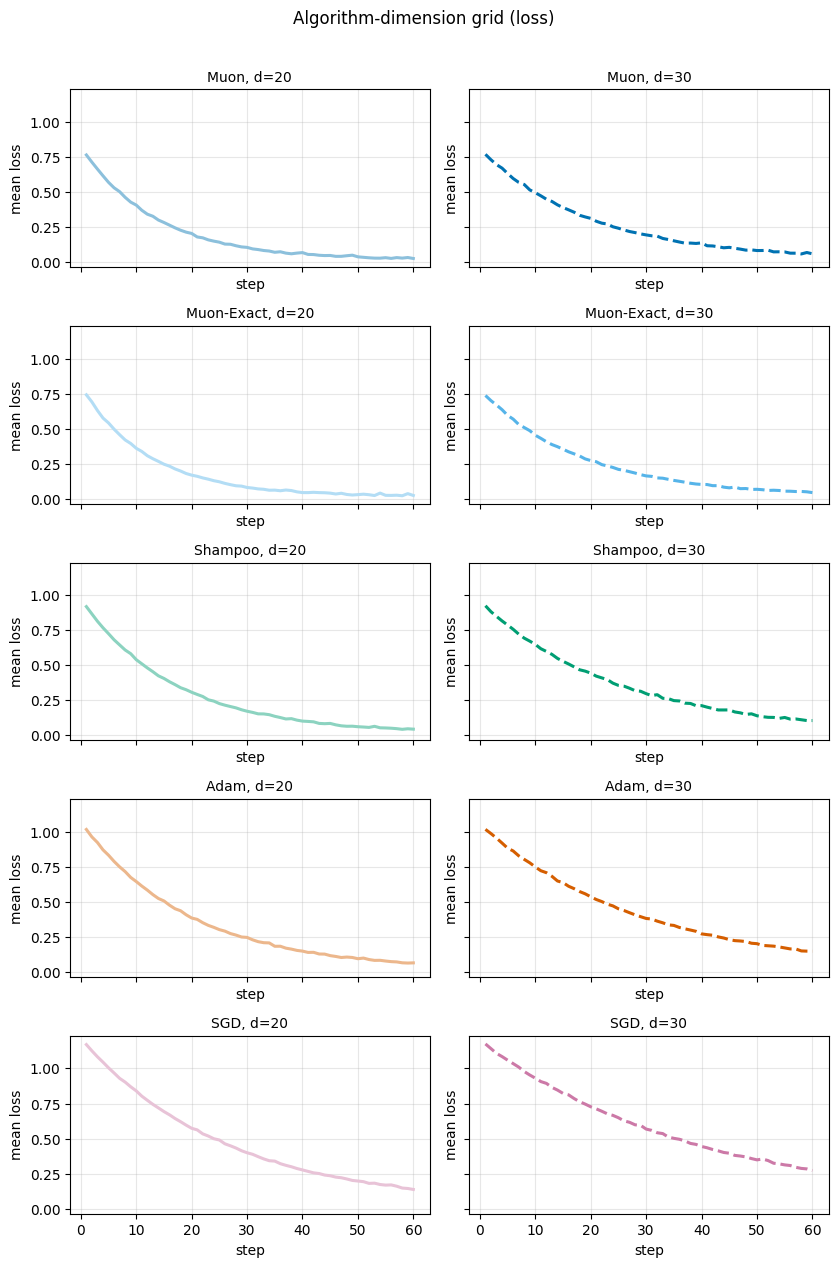

In [10]:
fig, axes = plot_algorithm_dimension_grid(trajectories)
show_figure(fig)

## Seed Variability

This fixes one dimension and expands the seed dimension. The horizontal axis is step, the vertical axis is individual-run loss, color is optimizer, and each faint curve is one seed. It demonstrates how to show run-to-run variability instead of only seed averages.

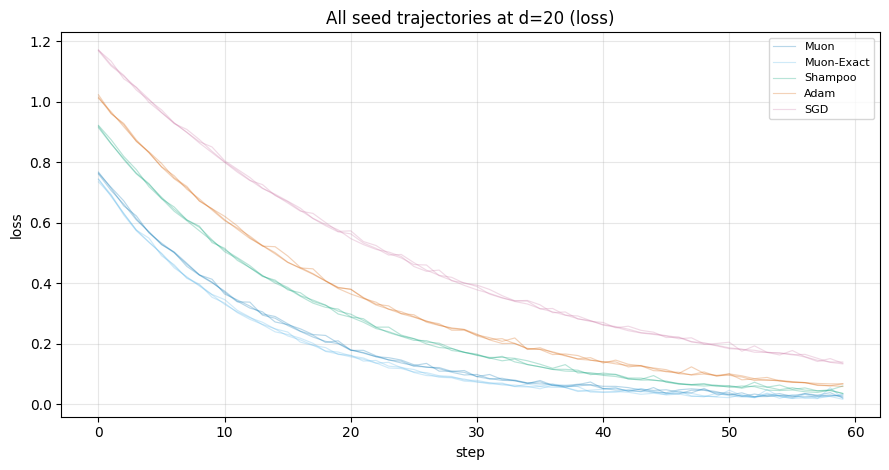

In [11]:
fig, ax = plot_seed_variability_for_dimension(trajectories, d=20)
show_figure(fig)